(-2.890585451972702,
 2.890912942969679,
 -2.8908392560925127,
 2.8908392560925127)

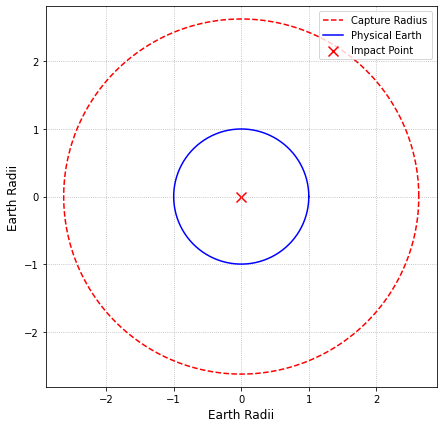

In [17]:
# Part 2
import numpy as np
import matplotlib.pyplot as plt

R_earth = 6378
mu_earth = 398600
V_ast = 34.5
V_earth = 29.9

V_esc = np.sqrt((2 * mu_earth) / R_earth)
V_inf = V_ast - V_earth

b_imp = R_earth * np.sqrt(1 + (V_esc**2 / V_inf**2))
b_imp_re = b_imp / R_earth

theta = np.linspace(0, 2 * np.pi, 200)
xi_earth = np.cos(theta)
zeta_earth = np.sin(theta)
xi_grav = b_imp_re * np.cos(theta)
zeta_grav = b_imp_re * np.sin(theta)

plt.figure(figsize=(7,7))
plt.plot(xi_grav, zeta_grav, 'r--', label=f'Capture Radius')
plt.plot(xi_earth, zeta_earth, 'b-', label='Physical Earth')

plt.scatter(0, 0, color='red', marker='x', s=100, label='Impact Point')

plt.xlabel(r'Earth Radii', fontsize=12)
plt.ylabel(r'Earth Radii', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':')
plt.axis('equal')

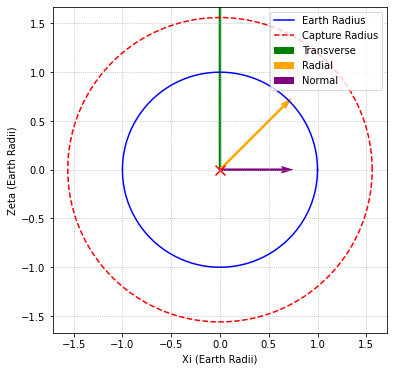

In [19]:
# Part 5
import numpy as np
import matplotlib.pyplot as plt

R_earth = 6378
mu_sun = 1.3271244e11
AU = 149597870.7

e = 0.19293483
q = 0.74161536 * AU
a = q / (1 - e)    
T_lead = 134  
T_sec = T_lead * 86400
dv = 0.001 

transverse = (3 * dv * T_sec) / R_earth

radial = (3 * dv * T_sec * e) / R_earth

v_orb = np.sqrt(mu_sun / a)
normal = ((dv / v_orb) * (1.0 * AU)) / R_earth

theta = np.linspace(0, 2 * np.pi, 200)
plt.figure(figsize=(6,6))

plt.plot(np.cos(theta), np.sin(theta), 'b-', label='Earth Radius')

b_imp_re = 1.56 
plt.plot(b_imp_re * np.cos(theta), b_imp_re * np.sin(theta), 'r--', label='Capture Radius')

plt.quiver(0, 0, 0, transverse, angles='xy', scale_units='xy', scale=1, 
           color='green', label=f'Transverse')

plt.quiver(0, 0, radial * 0.7, radial * 0.7, angles='xy', scale_units='xy', scale=1, 
           color='orange', label=f'Radial')

plt.quiver(0, 0, normal, 0, angles='xy', scale_units='xy', scale=1, 
           color='purple', label=f'Normal')

plt.scatter(0, 0, color='red', marker='x', s=100)
plt.xlabel('Xi (Earth Radii)')
plt.ylabel('Zeta (Earth Radii)')
plt.legend(loc='upper right')
plt.axis('equal')
plt.grid(True, linestyle=':')
plt.show()

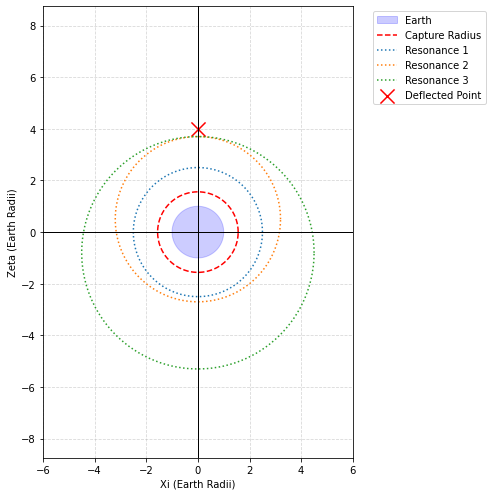

In [30]:
# Part 6
import numpy as np
import matplotlib.pyplot as plt

R_earth = 6378
b_imp_re = 1.56
V_earth = 29.9

resonances = [
    {'name': '1', 'radius': 2.5, 'offset': 0.0},
    {'name': '2', 'radius': 3.2, 'offset': 0.5},
    {'name': '3', 'radius': 4.5, 'offset': -0.8}
]

deflected_xi = 0.0
deflected_zeta = 4.0 

plt.figure(figsize=(7,7))
theta = np.linspace(0, 2 * np.pi, 500)

plt.fill(R_earth / R_earth * np.cos(theta), R_earth / R_earth * np.sin(theta), color='blue', alpha=0.2, label='Earth')
plt.plot(b_imp_re * np.cos(theta), b_imp_re * np.sin(theta), 'r--', label='Capture Radius')

for i, res in enumerate(resonances):
    circle_x = res['radius'] * np.cos(theta)
    circle_y = res['radius'] * np.sin(theta) + res['offset']
    plt.plot(circle_x, circle_y, linestyle=':', label=f'Resonance {res["name"]}')

plt.scatter(deflected_xi, deflected_zeta, color='red', marker='x', s=200, label='Deflected Point')

plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.xlabel(r'Xi (Earth Radii)')
plt.ylabel(r'Zeta (Earth Radii)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.tight_layout()
plt.show()